# Project: Exploring U.S. Obesity, Nutrition, and Physical Activity Patterns (BRFSS Indicators)

**Course:** DSCI 521 : Data Analysis and Interpretation   
**Team:** The OGs  
**Date:** January 20, 2026   

### Phase 1 Goal
This notebook conducts **exploratory data analysis (EDA)** on curated BRFSS-based public health indicators to identify meaningful patterns and disparities across geography and demographic groups. The emphasis in Phase 1 is on **data understanding, visualization, and interpretation**, while outlining a clear roadmap for deeper modeling in Phase 2.


#### Team Members
 - Akhil Tom
 - Sapan Parikh
 - Rishabh Gujarathi
 - Yugeshkanna Venkatesh

## 1. Problem Statement and Motivation

Obesity and physical inactivity are major public health challenges in the United States, associated with higher risk of chronic disease, reduced quality of life, and increased healthcare burden. While individual behavior influences outcomes, health patterns are also shaped by **socioeconomic conditions, access to resources, and geographic variation**.

### Research Questions (Phase 1)
- How do obesity-related indicators vary across U.S. states and over time?
- Which demographic breakouts (e.g., sex, income, education, race/ethnicity, age group) show the largest disparities?
- Do indicators such as physical inactivity tend to co-occur with higher obesity prevalence at the state level?

### Reason
This analysis can support public health agencies, policymakers, and researchers by identifying high-burden areas and groups, and by generating hypotheses for targeted interventions.


## 2. Dataset and Source

This project uses the **Nutrition, Physical Activity, and Obesity (BRFSS)** dataset, which contains curated health indicators derived from the CDC’s Behavioral Risk Factor Surveillance System (BRFSS) and is distributed publicly via Data.gov.

### Why this dataset is appropriate for Phase 1
- Official, public, and widely used in public health analytics  
- Structured and analysis-ready (CSV)  
- Multi-year, multi-state indicators with demographic breakdowns  
- Ideal for Phase 1 emphasis on EDA and interpretable visualizations

**Note:** This dataset is indicator-level (aggregated) rather than individual-level survey microdata. This supports clear exploratory analysis in Phase 1 while leaving open the option to extend to individual-level BRFSS data in Phase 2.


## 3. Work Plan 

This notebook follows a report-style flow:

1. Load and inspect the dataset structure  
2. Identify key columns, standardize numeric measurement fields, and handle missing values  
3. Scope to a small set of interpretable indicators for Phase 1 (e.g., obesity, inactivity)  
4. Perform EDA using descriptive statistics and visualizations:
   - Geographic differences (by state)
   - Trends over time
   - Disparities across demographic breakouts  
5. Summarize key findings, limitations, and a Phase 2 roadmap


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 4. Load Data

We begin by loading the dataset and checking basic properties (number of rows/columns, column names, and example records). We also identify the primary numeric value field that represents each indicator measurement.


In [3]:
data = "Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv" 
df = pd.read_csv(data)

df.shape, df.columns[:20]

/tmp/ipykernel_4564/3253101997.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data)


((110880, 33),
 Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'Datasource',
        'Class', 'Topic', 'Question', 'Data_Value_Unit', 'Data_Value_Type',
        'Data_Value', 'Data_Value_Alt', 'Data_Value_Footnote_Symbol',
        'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit ',
        'Sample_Size', 'Total', 'Age(years)', 'Education'],
       dtype='object'))

In [5]:
df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS


## 5. Understanding the Dataset Schema

This dataset is typically organized around:

- **Time:** Year start/end or reporting year  
- **Location:** State or national descriptor  
- **Indicator metadata:** Topic/Class/Question describing the measure  
- **Breakouts:** Demographic stratification category and group (e.g., Sex: Male/Female; Income levels)  
- **Measurement:** A numeric field (often a percentage) representing the indicator value  
- **Uncertainty:** Confidence interval bounds

Next, we verify these components in the dataset and convert the measurement field to numeric.


In [6]:
df.columns

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'Datasource',
       'Class', 'Topic', 'Question', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Alt', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit ',
       'Sample_Size', 'Total', 'Age(years)', 'Education', 'Sex', 'Income',
       'Race/Ethnicity', 'GeoLocation', 'ClassID', 'TopicID', 'QuestionID',
       'DataValueTypeID', 'LocationID', 'StratificationCategory1',
       'Stratification1', 'StratificationCategoryId1', 'StratificationID1'],
      dtype='object')

In [7]:
value_col_candidates = [c for c in df.columns if c.lower() in ["data_value", "datavalue", "value"]]
value_col_candidates

['Data_Value']

In [7]:
# Convert Data_Value to numeric 
df["Data_Value"] = pd.to_numeric(df["Data_Value"], errors="coerce")

# Basic check
df["Data_Value"].describe()

count    97666.000000
mean        31.800252
std         10.343087
min          0.900000
25%         24.900000
50%         31.800000
75%         37.400000
max         85.300000
Name: Data_Value, dtype: float64

In [8]:
df["Data_Value"].isna().mean()

np.float64(0.11917388167388167)

## 6. Phase 1 Scope and Focus

Because the dataset contains many indicators, Phase 1 focuses on a small, high-impact subset that is widely interpretable and relevant to public health decision-making.

### Primary focus
- Adult obesity prevalence (or a closely related obesity measure)

### Supporting indicators 
- Physical inactivity  
- Selected nutrition indicators (e.g., fruit/vegetable intake)

### Analytic focus
- Compare values across states  
- Examine trends across years  
- Compare disparities across major demographic breakouts (e.g., sex, income, education, race/ethnicity, age)


In [9]:
# Find columns that likely contain the indicator/question text
text_cols = [c for c in df.columns if df[c].dtype == "object"]
text_cols[:20]

['LocationAbbr',
 'LocationDesc',
 'Datasource',
 'Class',
 'Topic',
 'Question',
 'Data_Value_Unit',
 'Data_Value_Type',
 'Data_Value_Footnote_Symbol',
 'Data_Value_Footnote',
 'Total',
 'Age(years)',
 'Education',
 'Sex',
 'Income',
 'Race/Ethnicity',
 'GeoLocation',
 'ClassID',
 'TopicID',
 'QuestionID']

In [10]:
mask = np.zeros(len(df), dtype=bool)
for c in text_cols:
    mask |= df[c].astype(str).str.contains("obes", case=False, na=False)

df_ob = df[mask].copy()
df_ob.shape


(43120, 33)

In [11]:
for c in text_cols:
    if df_ob[c].nunique() < 50 and df_ob[c].nunique() > 1:
        print(c, df_ob[c].unique()[:10])


Question ['Percent of adults aged 18 years and older who have obesity'
 'Percent of adults aged 18 years and older who have an overweight classification']
Age(years) [nan '18 - 24' '25 - 34' '35 - 44' '45 - 54' '55 - 64' '65 or older']
Education [nan 'College graduate' 'High school graduate' 'Less than high school'
 'Some college or technical sch' 'Some college or technical school']
Sex [nan 'Female' 'Male']
Income ['$15,000 - $24,999' '$25,000 - $34,999' '$35,000 - $49,999'
 '$50,000 - $74,999' '$75,000 or greater' nan 'Data not reported'
 'Less than $15,000']
Race/Ethnicity [nan '2 or more races' 'American Indian/Alaska Native' 'Asian'
 'Hawaiian/Pacific Islander' 'Hispanic' 'Non-Hispanic Black'
 'Non-Hispanic White' 'Other']
QuestionID ['Q036' 'Q037']
StratificationCategory1 ['Income' 'Age (years)' 'Race/Ethnicity' 'Education' 'Sex' 'Total']
Stratification1 ['$15,000 - $24,999' '$25,000 - $34,999' '$35,000 - $49,999'
 '$50,000 - $74,999' '$75,000 or greater' '18 - 24' '2 or more rac

In [9]:
# Filter to obesity-related indicators
df_obesity = df[df["Topic"].str.contains("Obesity", case=False, na=False)].copy()

df_obesity.shape


(43120, 33)

In [11]:
PRIMARY_QUESTION = "Percent of adults aged 18 years and older who have obesity"

df_obesity = df[
    (df["Topic"].str.contains("Obesity", case=False, na=False)) &
    (df["Question"] == PRIMARY_QUESTION)
].copy()

df_obesity.shape

(21560, 33)

In [12]:
df_obesity["Question"].unique()

array(['Percent of adults aged 18 years and older who have obesity'],
      dtype=object)

## 7. Exploratory Data Analysis (EDA)

The EDA section is organized as follows:

- **Data completeness:** How much missingness exists in the numeric measurement field?  
- **Overall distributions:** What range of values is common across indicators?  
- **Geographic patterns:** Which states have consistently higher/lower indicator values?  
- **Time trends:** Are obesity-related indicators increasing or decreasing over time?  
- **Demographic disparities:** Which breakouts show the strongest gaps?  
- **Indicator relationships:** Do obesity and inactivity tend to move together at the state level?

Each visualization includes a short interpretation to keep the notebook self-explanatory.


### 7.1 Adult Obesity Prevalence by State (Latest Year)

We begin by comparing adult obesity prevalence across U.S. states using the most recent year available in the dataset.

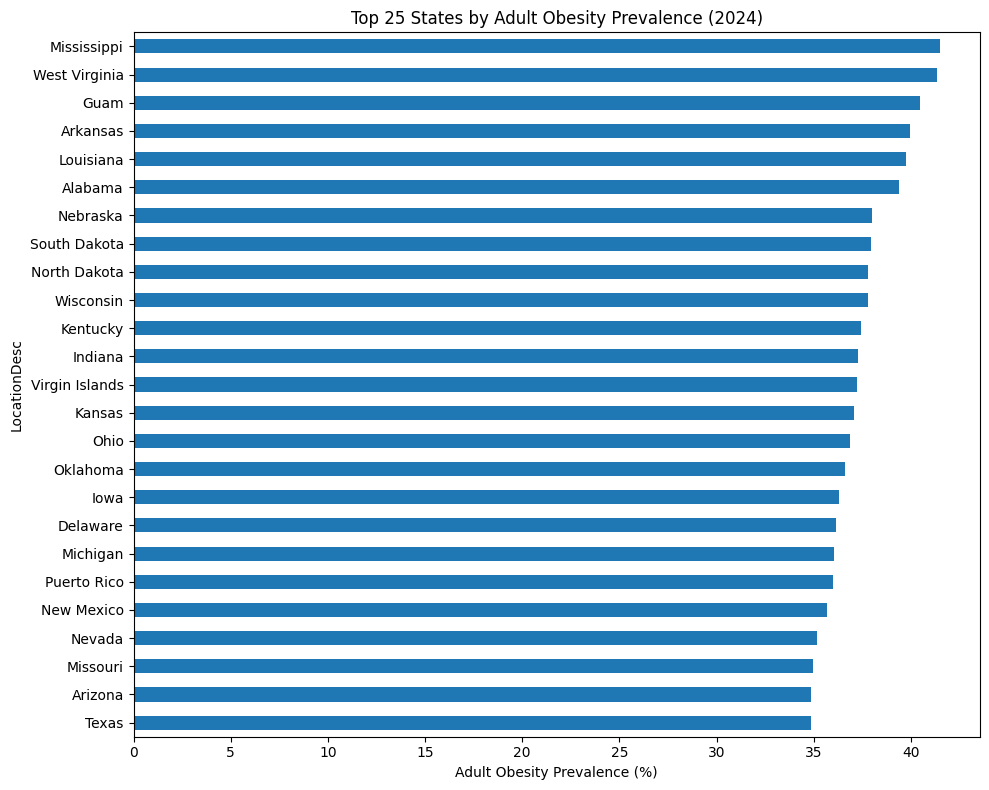

In [13]:
latest_year = df_obesity["YearStart"].max()

state_obesity = (
    df_obesity[df_obesity["YearStart"] == latest_year]
    .groupby("LocationDesc")["Data_Value"]
    .mean()
    .dropna()
    .sort_values()
)

plt.figure(figsize=(10, 8))
state_obesity.tail(25).plot(kind="barh")
plt.xlabel("Adult Obesity Prevalence (%)")
plt.title(f"Top 25 States by Adult Obesity Prevalence ({latest_year})")
plt.tight_layout()
plt.show()

**Interpretation:**  
Adult obesity prevalence varies substantially across U.S. states. The highest-prevalence states exhibit markedly higher values than others, suggesting that geographic, socioeconomic, and policy-related factors may play an important role in shaping population health outcomes.

### 7.2 Distribution of Adult Obesity Prevalence

This histogram shows the overall distribution of adult obesity prevalence values across all states, years, and demographic breakouts included in the dataset.

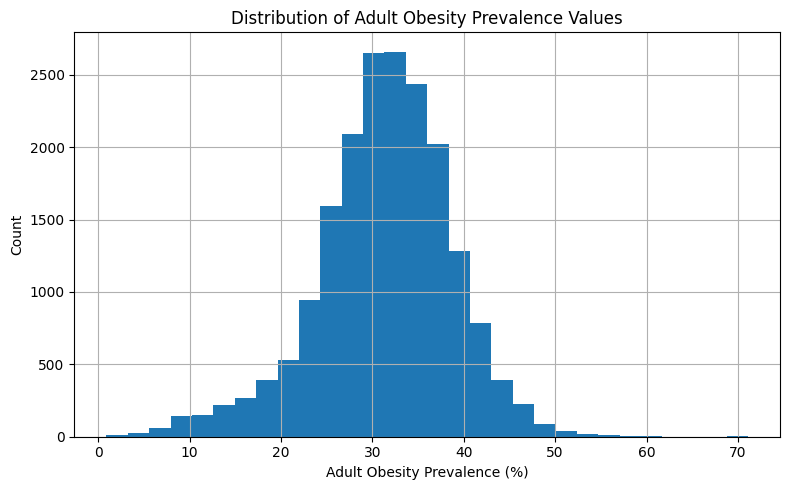

In [15]:
plt.figure(figsize=(8, 5))
df_obesity["Data_Value"].dropna().hist(bins=30)
plt.xlabel("Adult Obesity Prevalence (%)")
plt.ylabel("Count")
plt.title("Distribution of Adult Obesity Prevalence Values")
plt.tight_layout()
plt.show()

**Interpretation:**  
The distribution illustrates the range and concentration of obesity prevalence values observed across the dataset. Most observations fall within a moderate range, while fewer cases appear at very low or very high prevalence levels, indicating meaningful variation across populations and contexts.

### 7.3 Trend in Adult Obesity Prevalence Over Time

To assess temporal patterns, we examine how average adult obesity prevalence has changed across years.

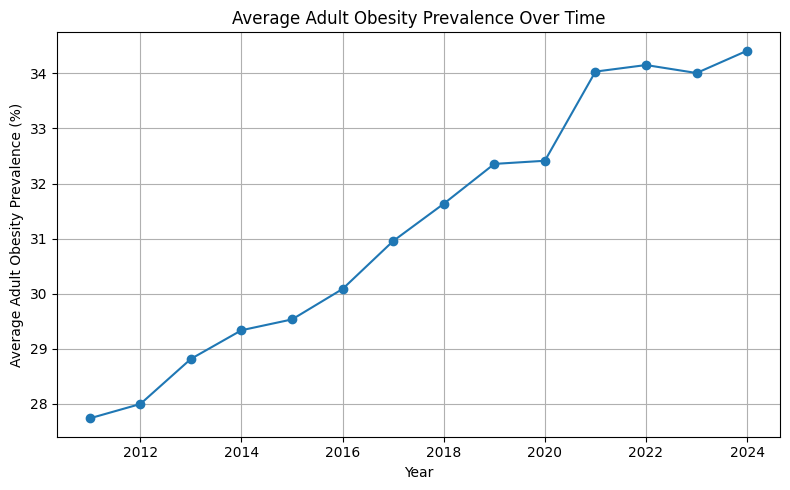

In [17]:
trend = (
    df_obesity
    .groupby("YearStart")["Data_Value"]
    .mean()
    .dropna()
)

plt.figure(figsize=(8, 5))
trend.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Average Adult Obesity Prevalence (%)")
plt.title("Average Adult Obesity Prevalence Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:**  
The line plot suggests a clear temporal trend in adult obesity prevalence over the observed years. Changes over time highlight the importance of longitudinal analysis when evaluating public health outcomes and potential policy impacts.

### 7.4 Trends in Adult Obesity Prevalence by Income Level

To better understand how socioeconomic disparities evolve over time, we examine trends in average adult obesity prevalence across income categories.


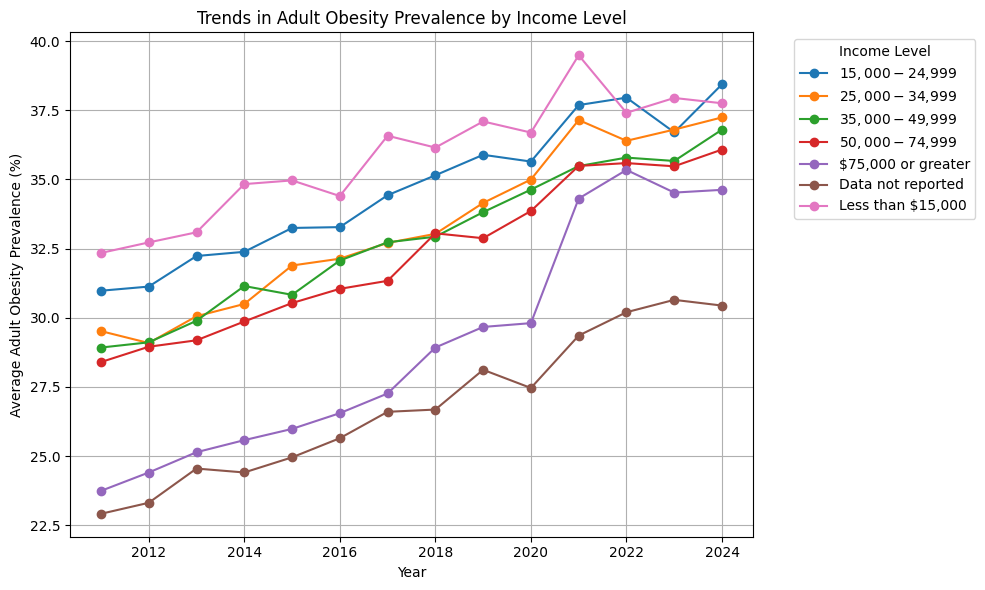

In [23]:
income_trend = (
    df_obesity[df_obesity["Income"].notna()]
    .groupby(["YearStart", "Income"])["Data_Value"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for income in income_trend["Income"].unique():
    subset = income_trend[income_trend["Income"] == income]
    plt.plot(
        subset["YearStart"],
        subset["Data_Value"],
        marker="o",
        label=income
    )

plt.xlabel("Year")
plt.ylabel("Average Adult Obesity Prevalence (%)")
plt.title("Trends in Adult Obesity Prevalence by Income Level")
plt.legend(title="Income Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:**  
Obesity prevalence trends differ across income groups, with some lower-income categories exhibiting consistently higher average values over time. The persistence of these gaps suggests that socioeconomic disparities in obesity are not only present but may be structurally embedded, motivating equity-focused public health interventions.


### 7.5 Adult Obesity Prevalence by Income Level

This box plot examines how obesity prevalence varies across income categories, providing insight into socioeconomic disparities.

<Figure size 1000x500 with 0 Axes>

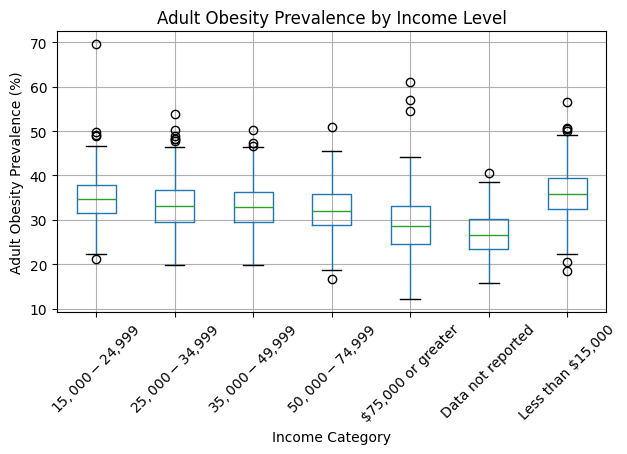

In [22]:
income_df = df_obesity[df_obesity["Income"].notna()]

plt.figure(figsize=(10, 5))
income_df.boxplot(column="Data_Value", by="Income", rot=45)
plt.xlabel("Income Category")
plt.ylabel("Adult Obesity Prevalence (%)")
plt.title("Adult Obesity Prevalence by Income Level")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Interpretation:**  
Obesity prevalence differs noticeably across income groups, with some lower-income categories exhibiting higher median values. This pattern underscores the role of socioeconomic conditions in shaping health outcomes and motivates equity-focused public health interventions.

## 8. Key Findings (Summary)

Based on the Phase 1 exploratory analysis, several consistent patterns emerge:

- **Geographic variation:** Adult obesity prevalence varies substantially across U.S. states, with some states consistently exhibiting higher prevalence than others.
- **Temporal trend:** Average adult obesity prevalence shows a clear upward trend over time, highlighting the importance of longitudinal public health monitoring.
- **Distributional spread:** Obesity prevalence values are concentrated within a moderate range, but meaningful variability exists across states, years, and demographic breakouts.
- **Sex disparities:** Differences in the distribution of obesity prevalence across sex categories suggest uneven burden across populations.
- **Socioeconomic gradient:** Obesity prevalence differs noticeably across income levels, with some lower-income groups exhibiting higher median values, underscoring the role of socioeconomic conditions in shaping health outcomes.

These findings are descriptive and motivate deeper analytical investigation in subsequent phases.


## 9. Limitations

This Phase 1 analysis has several important limitations:

- The dataset contains **aggregated indicator-level data**, not individual-level survey responses, which limits causal inference and granular modeling.
- Measures are derived from **self-reported survey data**, which may introduce reporting bias.
- Not all demographic breakouts are available uniformly across states and years, affecting direct comparability.
- Observed relationships are **associational only** and do not imply causation.

Despite these limitations, the dataset is well-suited for exploratory analysis and hypothesis generation.

## 10. Phase 2 Roadmap

In Phase 2, this project will extend beyond exploratory analysis to support deeper analytics and potential application development. Planned next steps include:

1. **Predictive modeling (indicator-level):** Estimate obesity indicator values using correlated indicators (e.g., inactivity, nutrition metrics) and selected demographic breakdowns.  
2. **Model comparison:** Compare multiple approaches (e.g., linear regression, regularization, tree-based models) using a clear validation strategy.  
3. **Interpretability:** Identify which features/indicators contribute most to predictions (feature importance / coefficient analysis).  
4. **Equity lens:** Assess which groups or locations remain persistently high-burden over time and whether disparities widen or narrow.  

If feasible, future work may incorporate individual-level BRFSS microdata to enable survey-weighted, person-level analysis.


## 11. References

- Data.gov: *Nutrition, Physical Activity, and Obesity — Behavioral Risk Factor Surveillance System (BRFSS)*  
- CDC BRFSS program overview and documentation (for survey background and indicator definitions)
